# MathArena Category Difficulty — Visualization
This notebook loads your split datasets, simulates small-model performance, and produces category-level difficulty plots.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(42)

train_path = Path("data/problem_type_data.train.csv")
test_path  = Path("data/problem_type_data.test.csv")

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

problem_type_col = "problem_type"
question_col = "problem"

#### Maps messy/variant category labels into a small, consistent set:

* Converts to lowercase, trims spaces.

* Looks up the text in alias lists; if matched, returns a canonical title-cased name (e.g., "algebra" → "Algebra").

* If no match, it just title-cases the original string.

* If missing/NaN, returns "Unknown"

In [3]:
def normalize_category(x):
    if pd.isna(x):
        return "Unknown"
    x = str(x).strip()
    x_low = x.lower()
    aliases = {
        "algebra": ["algebra", "algebra i", "algebra ii"],
        "geometry": ["geometry", "euclidean geometry", "geo"],
        "number theory": ["number theory", "nt"],
        "combinatorics": ["combinatorics", "counting", "combi"],
        "probability": ["probability", "prob"],
        "precalculus": ["precalculus", "functions", "trig", "trigonometry"],
    }
    for canon, variants in aliases.items():
        if any(v in x_low for v in variants):
            return canon.title()
    return x.title()

#### For each dataframe:

* Creates a new column category from problem_type, normalized using the function above.

* If problem_type doesn’t exist, sets category to "Unknown".

In [ ]:
# text_len: number of characters in the problem text.
# num_digits: how many numeric digits (0–9) appear in the text.
# If the problem column doesn’t exist, both features are set to 0.

for df in (train, test):
    if problem_type_col in df.columns:
        df["category"] = df[problem_type_col].apply(normalize_category)
    else:
        df["category"] = "Unknown"
    if question_col in df.columns:
        df["text_len"] = df[question_col].astype(str).str.len()
        df["num_digits"] = df[question_col].astype(str).str.count(r"\d")
    else:
        df["text_len"] = 0
        df["num_digits"] = 0

# A small dictionary to detect category-specific words in the problem text. 
KEYWORDS = {
    "Algebra": ["equation", "variable", "polynomial", "linear", "quadratic", "system"],
    "Geometry": ["triangle", "circle", "angle", "area", "perimeter", "radius", "point"],
    "Number Theory": ["divisible", "prime", "gcd", "lcm", "remainder", "mod"],
    "Combinatorics": ["ways", "choose", "permutation", "combination", "arrange"],
}

# Counts how many keywords for the given category appear in the lowercased problem text (e.g., for a Geometry problem, how many of the geometry words are present).
def keyword_score(text, category):
    if pd.isna(text):
        return 0
    text_low = str(text).lower()
    keys = KEYWORDS.get(category, [])
    return sum(1 for k in keys if k in text_low)

#### Each entry gives parameters for a simple probability model of getting a problem correct:

* base: baseline correctness probability.

* len_penalty: subtracts probability for longer problems.

* digit_boost: adds probability when more digits appear.

* keyword_mult: boosts probability by how many category keywords match.

In [ ]:

MODELS = {
    "RandomBaseline": {"base": 0.25, "len_penalty": 0.00, "digit_boost": 0.00, "keyword_mult": 0.00},
    "TinyLenNet": {"base": 0.45, "len_penalty": 0.0008, "digit_boost": 0.02, "keyword_mult": 0.03},
    "KeywordMatcher": {"base": 0.40, "len_penalty": 0.0004, "digit_boost": 0.00, "keyword_mult": 0.08},
    "NumFriendly": {"base": 0.42, "len_penalty": 0.0005, "digit_boost": 0.04, "keyword_mult": 0.02},
}

#### For one problem (row) and one model:

* Start at base.

* Penalize for length.

* Boost for numeric digits.

* Boost more if several category keywords are present.

* Clamp final probability into [0.03, 0.95] to avoid 0/1 extremes.

In [6]:
def simulate_model_correct_prob(row, model_params):
    p = model_params["base"]
    p -= model_params["len_penalty"] * float(row["text_len"])
    p += model_params["digit_boost"] * float(row["num_digits"])
    ks = keyword_score(row.get(question_col, ""), row["category"])
    p += model_params["keyword_mult"] * ks
    return float(np.clip(p, 0.03, 0.95))

# Simulate per-problem predictions
#### For each model:

* Computes a probability of being correct for every problem.

* Draws a Bernoulli random variable (0/1) with that probability to mark the problem as correct or not.

* Stores both the probability and the binary outcome in new columns like TinyLenNet_prob and TinyLenNet_correct.

In [7]:
def simulate_predictions(df):
    df = df.copy()
    for model_name, params in MODELS.items():
        probs = df.apply(lambda r: simulate_model_correct_prob(r, params), axis=1)
        df[f"{model_name}_prob"] = probs
        df[f"{model_name}_correct"] = np.random.binomial(1, probs).astype(int)
    return df

sim_train = simulate_predictions(train)
sim_test = simulate_predictions(test)


# Aggregate accuracy by category
#### Groups problems by category.

For each category:

* Counts how many problems are in it (n_problems).

* Computes accuracy per model = mean of that model’s _correct (0/1) column.

* Computes avg_acc_across_models by averaging the model accuracies (a crude “difficulty”: lower = harder).

* Returns a dataframe sorted by the average accuracy (so hardest categories appear first).

In [8]:
def agg_category(df):
    rows = []
    for cat, g in df.groupby("category"):
        row = {"category": cat, "n_problems": len(g)}
        for m in MODELS:
            row[f"{m}_acc"] = g[f"{m}_correct"].mean() if len(g) else np.nan
        row["avg_acc_across_models"] = np.mean([row[f"{m}_acc"] for m in MODELS])
        rows.append(row)
    return pd.DataFrame(rows).sort_values("avg_acc_across_models")

summary_train = agg_category(sim_train)
summary_test = agg_category(sim_test)

summary_train.to_csv("data/category_difficulty_train.csv", index=False)
summary_test.to_csv("data/category_difficulty_test.csv", index=False)

summary_train, summary_test

(        category  n_problems  RandomBaseline_acc  TinyLenNet_acc  \
 1  Combinatorics          18            0.277778        0.388889   
 0        Algebra          13            0.230769        0.384615   
 2       Geometry          20            0.150000        0.500000   
 3  Number Theory          14            0.285714        0.714286   
 
    KeywordMatcher_acc  NumFriendly_acc  avg_acc_across_models  
 1            0.111111         0.555556               0.333333  
 0            0.307692         0.692308               0.403846  
 2            0.350000         0.750000               0.437500  
 3            0.571429         0.857143               0.607143  ,
         category  n_problems  RandomBaseline_acc  TinyLenNet_acc  \
 1  Combinatorics          21            0.238095        0.333333   
 2       Geometry          20            0.250000        0.450000   
 3  Number Theory           6            0.166667        0.500000   
 0        Algebra          18            0.277778  

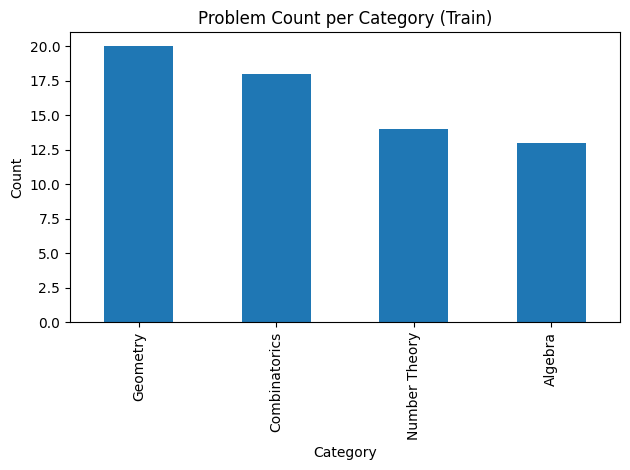

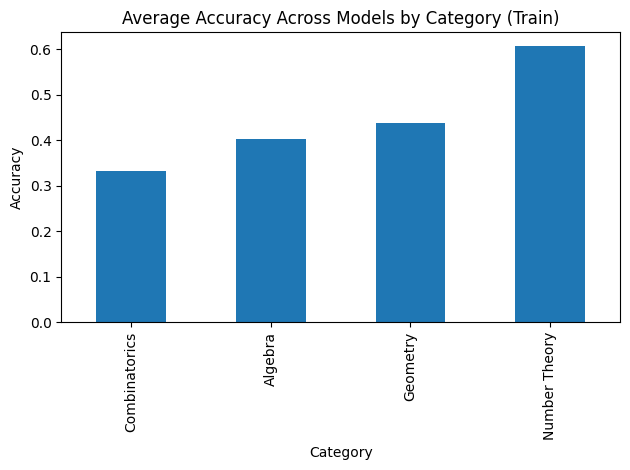

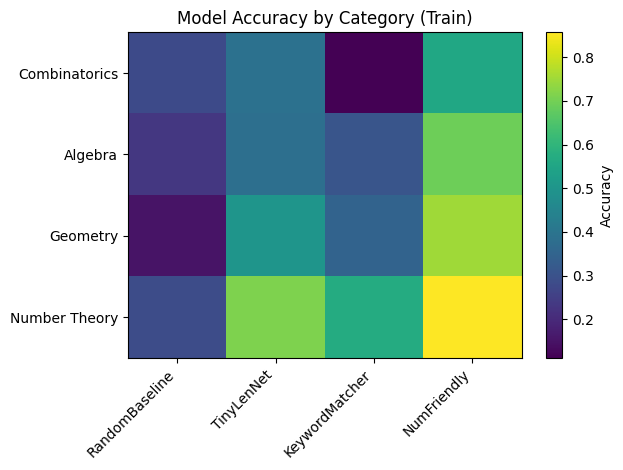

In [9]:

# Plots (Train)
import numpy as np

# 1) Count of problems per category
plt.figure()
sim_train["category"].value_counts().sort_values(ascending=False).plot(kind="bar")
plt.title("Problem Count per Category (Train)")
plt.xlabel("Category"); plt.ylabel("Count")
plt.tight_layout()

# 2) Average accuracy across models by category
plt.figure()
summary_train.sort_values("avg_acc_across_models").set_index("category")["avg_acc_across_models"].plot(kind="bar")
plt.title("Average Accuracy Across Models by Category (Train)")
plt.xlabel("Category"); plt.ylabel("Accuracy")
plt.tight_layout()

# 3) Heatmap-like chart for model vs. category
cats = list(summary_train["category"])
model_names = list(MODELS.keys())
acc_matrix = np.array([[summary_train.loc[summary_train["category"] == c, f"{m}_acc"].values[0] for m in model_names] for c in cats])

plt.figure()
plt.imshow(acc_matrix, aspect="auto")
plt.colorbar(label="Accuracy")
plt.yticks(range(len(cats)), cats)
plt.xticks(range(len(model_names)), model_names, rotation=45, ha="right")
plt.title("Model Accuracy by Category (Train)")
plt.tight_layout()


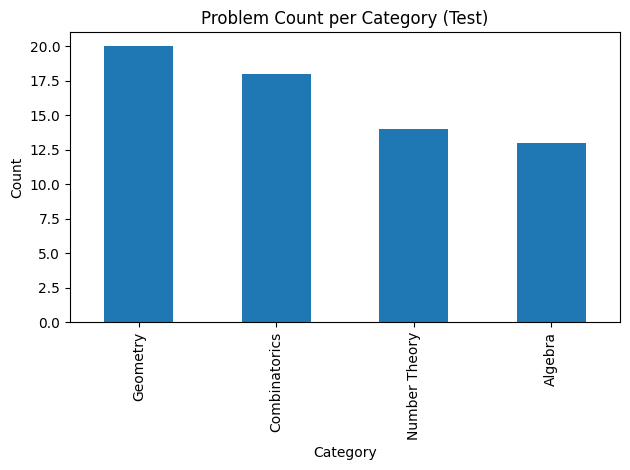

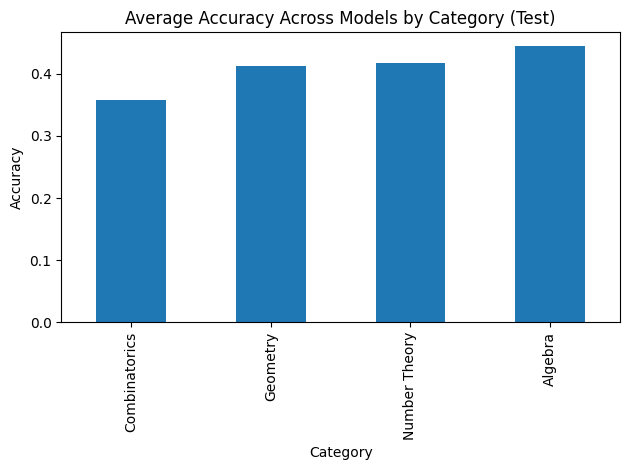

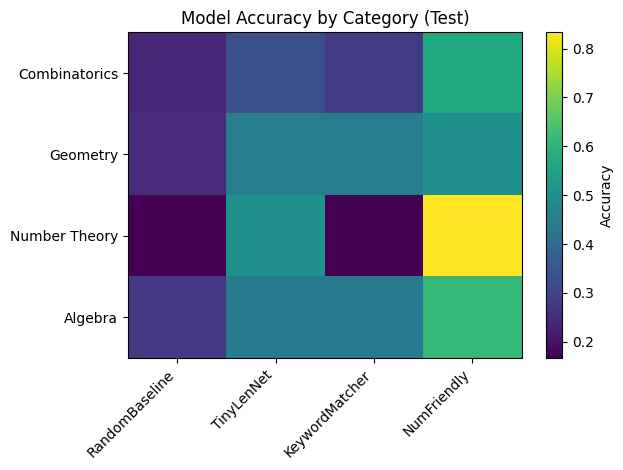

In [10]:

# Plots (test)
import numpy as np

# 1) Count of problems per category
plt.figure()
sim_train["category"].value_counts().sort_values(ascending=False).plot(kind="bar")
plt.title("Problem Count per Category (Test)")
plt.xlabel("Category"); plt.ylabel("Count")
plt.tight_layout()
plt.savefig("images/problem_count_per_category.png", dpi=300, bbox_inches="tight")

# 2) Average accuracy across models by category
plt.figure()
summary_test.sort_values("avg_acc_across_models").set_index("category")["avg_acc_across_models"].plot(kind="bar")
plt.title("Average Accuracy Across Models by Category (Test)")
plt.xlabel("Category"); plt.ylabel("Accuracy")
plt.tight_layout()
plt.savefig("images/average_accuracy_across_models_by_category.png", dpi=300, bbox_inches="tight")

# 3) Heatmap-like chart for model vs. category
cats = list(summary_test["category"])
model_names = list(MODELS.keys())
acc_matrix = np.array([[summary_test.loc[summary_test["category"] == c, f"{m}_acc"].values[0] for m in model_names] for c in cats])

plt.figure()
plt.imshow(acc_matrix, aspect="auto")
plt.colorbar(label="Accuracy")
plt.yticks(range(len(cats)), cats)
plt.xticks(range(len(model_names)), model_names, rotation=45, ha="right")
plt.title("Model Accuracy by Category (Test)")
plt.tight_layout()
plt.savefig("images/model_accuracy_by_category.png", dpi=300, bbox_inches="tight")


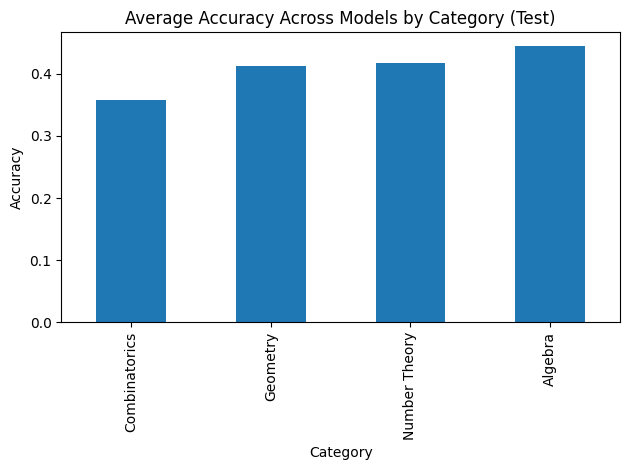

In [11]:

# Plots (Test)
plt.figure()
summary_test.sort_values("avg_acc_across_models").set_index("category")["avg_acc_across_models"].plot(kind="bar")
plt.title("Average Accuracy Across Models by Category (Test)")
plt.xlabel("Category"); plt.ylabel("Accuracy")
plt.tight_layout()
